# Bank Marketing - EDA & Feature Engineering

**Mục tiêu:** Phân tích dữ liệu Bank Marketing, xử lý unknown/outlier, feature engineering theo tư duy segmentation 2 tầng, và chuẩn bị data cho modeling.

In [47]:
# ============================================================
# ALL IMPORTS - Đưa về đầu file cho clean
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('All imports OK.')

All imports OK.


In [48]:
# ============================================================
# LOAD DATA
# ============================================================
df_raw = pd.read_csv('bank+marketing/bank/bank-full.csv', sep=';')
df = df_raw.copy()  # Giữ bản gốc để so sánh

# Tạo target binary ngay từ đầu để dùng xuyên suốt notebook
df['target'] = (df['y'] == 'yes').astype(int)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Target distribution: {df["target"].value_counts().to_dict()}')
df.head()

Shape: (45211, 18)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'target']
Target distribution: {0: 39922, 1: 5289}


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


---
## 1. DATA AUDIT
### 1.1 Kiểm tra null và unknown

In [49]:
# 1.1a - Null values (standard)
print('=== NULL VALUES ===')
print(df.isnull().sum())
print(f'\nTổng null: {df.isnull().sum().sum()}')

=== NULL VALUES ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
target       0
dtype: int64

Tổng null: 0


In [50]:
# 1.1b - Unknown values trong các cột categorical
cat_cols = df.select_dtypes(include='object').columns.tolist()

unknown_info = []
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    pct = count / len(df) * 100
    unknown_info.append({'Column': col, 'Unknown_Count': count, 'Percentage': round(pct, 2)})

unknown_df = pd.DataFrame(unknown_info)
unknown_df = unknown_df[unknown_df['Unknown_Count'] > 0].sort_values('Unknown_Count', ascending=False)

print('=== UNKNOWN VALUES ===')
print(unknown_df.to_string(index=False))
print(f'\nNhận xét: poutcome có 82% unknown => đây KHÔNG phải thiếu dữ liệu mà là pattern rõ ràng.')
print('82% khách CHƯA TỪNG được gọi trước đó => unknown = khách mới.')

=== UNKNOWN VALUES ===
   Column  Unknown_Count  Percentage
 poutcome          36959       81.75
  contact          13020       28.80
education           1857        4.11
      job            288        0.64

Nhận xét: poutcome có 82% unknown => đây KHÔNG phải thiếu dữ liệu mà là pattern rõ ràng.
82% khách CHƯA TỪNG được gọi trước đó => unknown = khách mới.


In [51]:
# 1.1c - Kiểm chứng: pdays == -1 khớp với poutcome == 'unknown'
pdays_neg1 = (df['pdays'] == -1).sum()
poutcome_unk = (df['poutcome'] == 'unknown').sum()

print(f'pdays == -1:          {pdays_neg1} ({pdays_neg1/len(df)*100:.2f}%)')
print(f'poutcome == unknown:  {poutcome_unk} ({poutcome_unk/len(df)*100:.2f}%)')
print(f'\n=> Khớp hoàn toàn! pdays=-1 <=> poutcome=unknown <=> Khách mới chưa từng được gọi.')

pdays == -1:          36954 (81.74%)
poutcome == unknown:  36959 (81.75%)

=> Khớp hoàn toàn! pdays=-1 <=> poutcome=unknown <=> Khách mới chưa từng được gọi.


### 1.2 Kiểm tra mối quan hệ unknown giữa education và job

In [52]:
# Kiểm tra: Khi education=unknown thì job có xu hướng gì?
edu_unk = df[df['education'] == 'unknown']
print(f'Số lượng education=unknown: {len(edu_unk)}')
print(f'\nPhân bố job khi education=unknown:')
print(edu_unk['job'].value_counts())

# Ngược lại: Khi job=unknown thì education?
job_unk = df[df['job'] == 'unknown']
print(f'\nSố lượng job=unknown: {len(job_unk)}')
print(f'\nPhân bố education khi job=unknown:')
print(job_unk['education'].value_counts())

# Crosstab
both_unk = ((df['education'] == 'unknown') & (df['job'] == 'unknown')).sum()
print(f'\nCả education VÀ job đều unknown: {both_unk}')
print(f'=> Có mối liên hệ: {both_unk} / {len(edu_unk)} education unknown cũng có job unknown.')

Số lượng education=unknown: 1857

Phân bố job khi education=unknown:
job
blue-collar      454
technician       242
management       242
admin.           171
student          163
services         150
unknown          127
retired          119
entrepreneur      76
housemaid         45
self-employed     39
unemployed        29
Name: count, dtype: int64

Số lượng job=unknown: 288

Phân bố education khi job=unknown:
education
unknown      127
secondary     71
primary       51
tertiary      39
Name: count, dtype: int64

Cả education VÀ job đều unknown: 127
=> Có mối liên hệ: 127 / 1857 education unknown cũng có job unknown.


### 1.3 Percentile Analysis - Phát hiện outlier
Bảng percentile chi tiết cho các biến số để xác định ngưỡng cắt.

In [53]:
# Percentile cho balance
print('=== BALANCE - Percentile ===')
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
balance_pct = df['balance'].quantile(percentiles)
for p, v in balance_pct.items():
    print(f'  {int(p*100):>3}%:  {v:>10,.0f}')
print(f'  min:  {df["balance"].min():>10,.0f}')
print(f'  max:  {df["balance"].max():>10,.0f}')

print(f'\n=> 99% = {balance_pct[0.99]:,.0f}, nhảy vọt so với 95% = {balance_pct[0.95]:,.0f}')
print('=> Cần cắt outlier ở đầu trên + xử lý số âm.')

# IQR method cho balance
Q25_b = df['balance'].quantile(0.25)
Q75_b = df['balance'].quantile(0.75)
IQR_b = Q75_b - Q25_b
upper_b = Q75_b + 1.5 * IQR_b
lower_b = Q25_b - 1.5 * IQR_b
print(f'\n--- IQR Method cho balance ---')
print(f'Q25={Q25_b:.0f}, Q75={Q75_b:.0f}, IQR={IQR_b:.0f}')
print(f'Ngưỡng dưới = {lower_b:.0f}, Ngưỡng trên = {upper_b:.0f}')
print(f'Outliers (IQR): {((df["balance"] < lower_b) | (df["balance"] > upper_b)).sum()} rows')

=== BALANCE - Percentile ===
    1%:        -627
    5%:        -172
   25%:          72
   50%:         448
   75%:       1,428
   95%:       5,768
   99%:      13,165
  min:      -8,019
  max:     102,127

=> 99% = 13,165, nhảy vọt so với 95% = 5,768
=> Cần cắt outlier ở đầu trên + xử lý số âm.

--- IQR Method cho balance ---
Q25=72, Q75=1428, IQR=1356
Ngưỡng dưới = -1962, Ngưỡng trên = 3462
Outliers (IQR): 4729 rows


In [54]:
# Percentile cho campaign
print('=== CAMPAIGN - Percentile ===')
campaign_pct = df['campaign'].quantile(percentiles)
for p, v in campaign_pct.items():
    print(f'  {int(p*100):>3}%:  {v:>6,.0f} lần')
print(f'  min:  {df["campaign"].min():>6,.0f} lần')
print(f'  max:  {df["campaign"].max():>6,.0f} lần')

print(f'\n=> 75% khách bị gọi tối đa {campaign_pct[0.75]:.0f} lần')
print(f'=> 99% = {campaign_pct[0.99]:.0f} lần, max = {df["campaign"].max()} lần => outlier cần cắt.')

# IQR method cho campaign
Q25_c = df['campaign'].quantile(0.25)
Q75_c = df['campaign'].quantile(0.75)
IQR_c = Q75_c - Q25_c
upper_c = Q75_c + 1.5 * IQR_c
lower_c = Q25_c - 1.5 * IQR_c
print(f'\n--- IQR Method cho campaign ---')
print(f'Q25={Q25_c:.0f}, Q75={Q75_c:.0f}, IQR={IQR_c:.0f}')
print(f'Ngưỡng trên = {upper_c:.0f}')
print(f'Outliers (IQR): {(df["campaign"] > upper_c).sum()} rows')

=== CAMPAIGN - Percentile ===
    1%:       1 lần
    5%:       1 lần
   25%:       1 lần
   50%:       2 lần
   75%:       3 lần
   95%:       8 lần
   99%:      16 lần
  min:       1 lần
  max:      63 lần

=> 75% khách bị gọi tối đa 3 lần
=> 99% = 16 lần, max = 63 lần => outlier cần cắt.

--- IQR Method cho campaign ---
Q25=1, Q75=3, IQR=2
Ngưỡng trên = 6
Outliers (IQR): 3064 rows


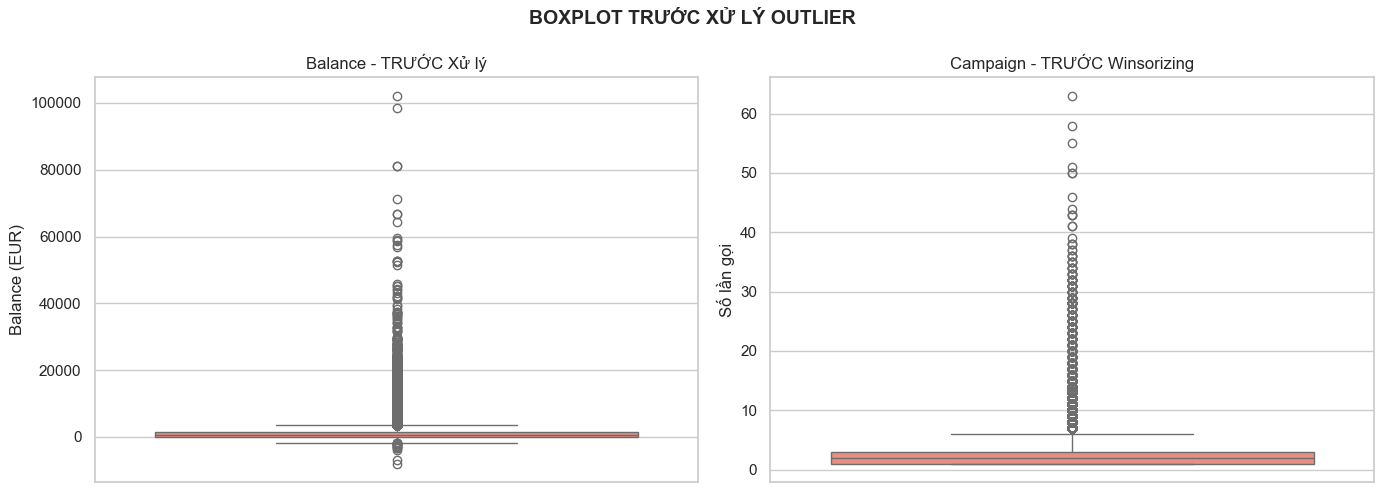

In [55]:
# BOXPLOT TRƯỚC khi xử lý - để so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['balance'], ax=axes[0], color='salmon')
axes[0].set_title('Balance - TRƯỚC Xử lý')
axes[0].set_ylabel('Balance (EUR)')

sns.boxplot(y=df['campaign'], ax=axes[1], color='salmon')
axes[1].set_title('Campaign - TRƯỚC Winsorizing')
axes[1].set_ylabel('Số lần gọi')

plt.suptitle('BOXPLOT TRƯỚC XỬ LÝ OUTLIER', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. XỬ LÝ OUTLIER & BALANCE ÂM
- **balance**: Đưa các giá trị âm về 0, sau đó Winsorize đầu trên (99%).
- **campaign**: Winsorize đầu trên (99%).

In [56]:
# Lưu giá trị trước để so sánh
balance_before_min = df['balance'].min()
balance_before_max = df['balance'].max()
campaign_before_max = df['campaign'].max()

# 1. Xử lý balance âm: Cắt về 0
df['balance'] = df['balance'].clip(lower=0)

# 2. Winsorize balance: Chỉ cắt 1% đầu trên
df['balance'] = winsorize(df['balance'], limits=[0, 0.01])

# 3. Winsorize campaign: Chỉ cắt 1% trên
df['campaign'] = winsorize(df['campaign'], limits=[0, 0.01])

print('=== KẾT QUẢ XỬ LÝ OUTLIER & BALANCE ÂM ===')
print(f'Balance: [{balance_before_min:,.0f}, {balance_before_max:,.0f}] => [{df["balance"].min():,.0f}, {df["balance"].max():,.0f}]')
print(f'Campaign: [max={campaign_before_max}] => [max={df["campaign"].max()}]')
print('\n=> Đã đưa balance âm về 0 và Winsorize đầu trên.')

=== KẾT QUẢ XỬ LÝ OUTLIER & BALANCE ÂM ===
Balance: [-8,019, 102,127] => [0, 13,165]
Campaign: [max=63] => [max=16]

=> Đã đưa balance âm về 0 và Winsorize đầu trên.


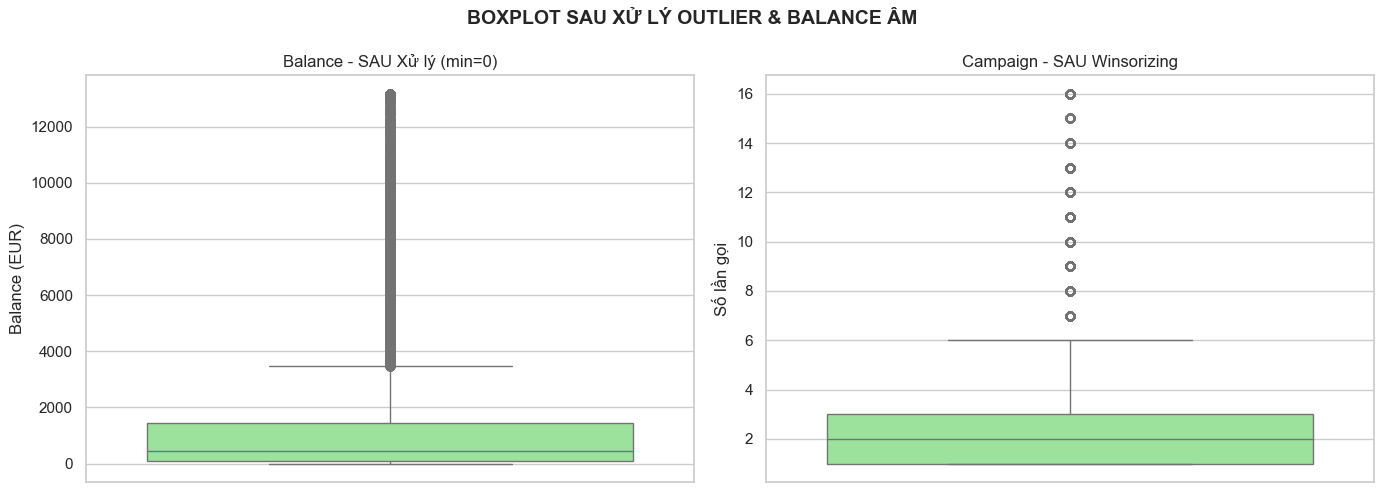

In [57]:
# BOXPLOT SAU khi xử lý
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['balance'], ax=axes[0], color='lightgreen')
axes[0].set_title('Balance - SAU Xử lý (min=0)')
axes[0].set_ylabel('Balance (EUR)')

sns.boxplot(y=df['campaign'], ax=axes[1], color='lightgreen')
axes[1].set_title('Campaign - SAU Winsorizing')
axes[1].set_ylabel('Số lần gọi')

plt.suptitle('BOXPLOT SAU XỬ LÝ OUTLIER & BALANCE ÂM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

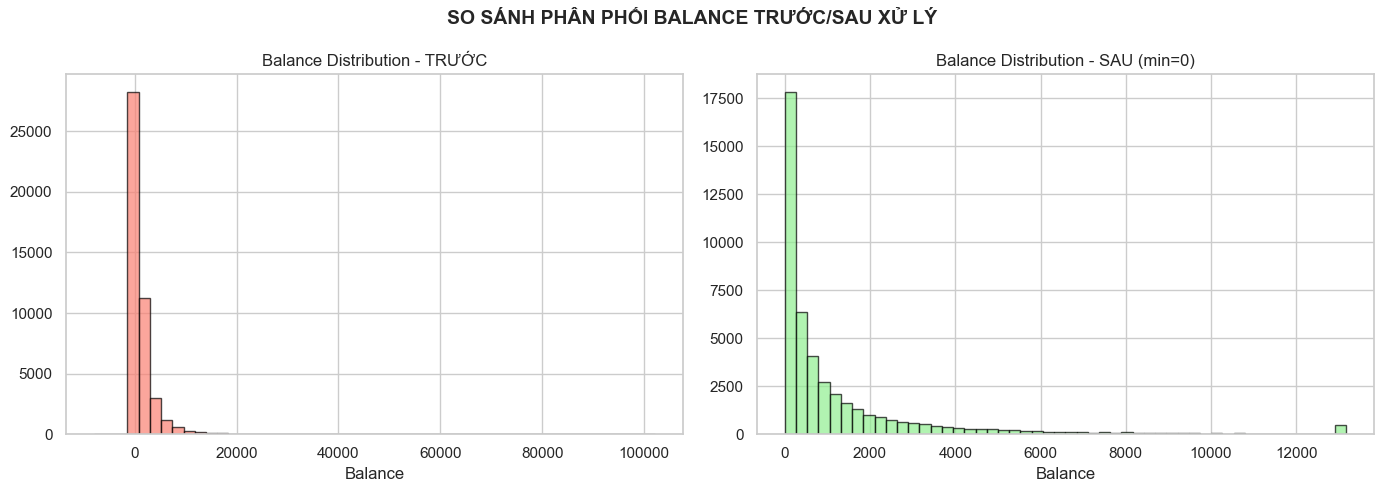

In [58]:
# Histogram before vs after cho balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['balance'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Balance Distribution - TRƯỚC')
axes[0].set_xlabel('Balance')

axes[1].hist(df['balance'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Balance Distribution - SAU (min=0)')
axes[1].set_xlabel('Balance')

plt.suptitle('SO SÁNH PHÂN PHỐI BALANCE TRƯỚC/SAU XỬ LÝ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. FEATURE ENGINEERING - Tư duy segmentation 2 tầng

**Insight chính:** poutcome có 4 giá trị: unknown (chưa gọi), failure (gọi từ chối), other (kết quả khác), success (gọi chốt được).

Thay vì để model học 4 nhóm một lúc (nhiễu), ta chia 2 tầng:

1. **Tầng 1**: `is_new_customer` - Khách này đã được gọi chưa? (tỉ lệ 82-18)
2. **Tầng 2**: `prev_success` - Trong số khách cũ, ai đã đồng ý? (1=success, 0=failure/other)

In [59]:
# ============================================================
# TẦNG 1: is_new_customer
# pdays == -1 => chưa từng được gọi => khách mới
# ============================================================
df['is_new_customer'] = (df['pdays'] == -1).astype(int)

print('=== TẦNG 1: is_new_customer ===')
print(df['is_new_customer'].value_counts())
print(f'\nKhách mới: {df["is_new_customer"].mean()*100:.1f}%')
print(f'Khách cũ: {(1-df["is_new_customer"].mean())*100:.1f}%')

=== TẦNG 1: is_new_customer ===
is_new_customer
1    36954
0     8257
Name: count, dtype: int64

Khách mới: 81.7%
Khách cũ: 18.3%


In [60]:
# ============================================================
# TẦNG 2: prev_success (chỉ có ý nghĩa với khách cũ)
# success => 1, failure/other => 0
# ============================================================
def map_prev_success(row):
    if row['is_new_customer'] == 1:
        return 0  # Khách mới, không có lịch sử
    elif row['poutcome'] == 'success':
        return 1
    else:  # failure hoặc other
        return 0

df['prev_success'] = df.apply(map_prev_success, axis=1)

# Xem phân bố trong nhóm khách cũ
existing = df[df['is_new_customer'] == 0]
print('=== TẦNG 2: prev_success (chỉ trong khách cũ) ===')
print(existing['prev_success'].value_counts())
print(f'\nTrong {len(existing)} khách cũ:')
print(f'  - Đã thành công trước: {existing["prev_success"].sum()}')
print(f'  - Chưa thành công: {len(existing) - existing["prev_success"].sum()}')

=== TẦNG 2: prev_success (chỉ trong khách cũ) ===
prev_success
0    6746
1    1511
Name: count, dtype: int64

Trong 8257 khách cũ:
  - Đã thành công trước: 1511
  - Chưa thành công: 6746


In [61]:
# ============================================================
# pdays_actual: thay -1 bằng 0 cho khách mới
# ============================================================
df['pdays_actual'] = df['pdays'].replace(-1, 0)

print('pdays_actual stats (khách cũ only):')
print(df[df['is_new_customer'] == 0]['pdays_actual'].describe())

pdays_actual stats (khách cũ only):
count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays_actual, dtype: float64


In [62]:
# ============================================================
# contact_known: biến nhị phân cho contact
# contact có 29% unknown
# ============================================================
df['contact_known'] = (df['contact'] != 'unknown').astype(int)

print('=== contact_known ===')
print(df['contact_known'].value_counts())
print(f'Tỉ lệ biết phương thức liên hệ: {df["contact_known"].mean()*100:.1f}%')

=== contact_known ===
contact_known
1    32191
0    13020
Name: count, dtype: int64
Tỉ lệ biết phương thức liên hệ: 71.2%


---
## 4. PHÂN TÍCH & VISUALIZATION

In [63]:
avg_conv = df['target'].mean()
print(f'Tỉ lệ conversion trung bình: {avg_conv:.2%}')

Tỉ lệ conversion trung bình: 11.70%


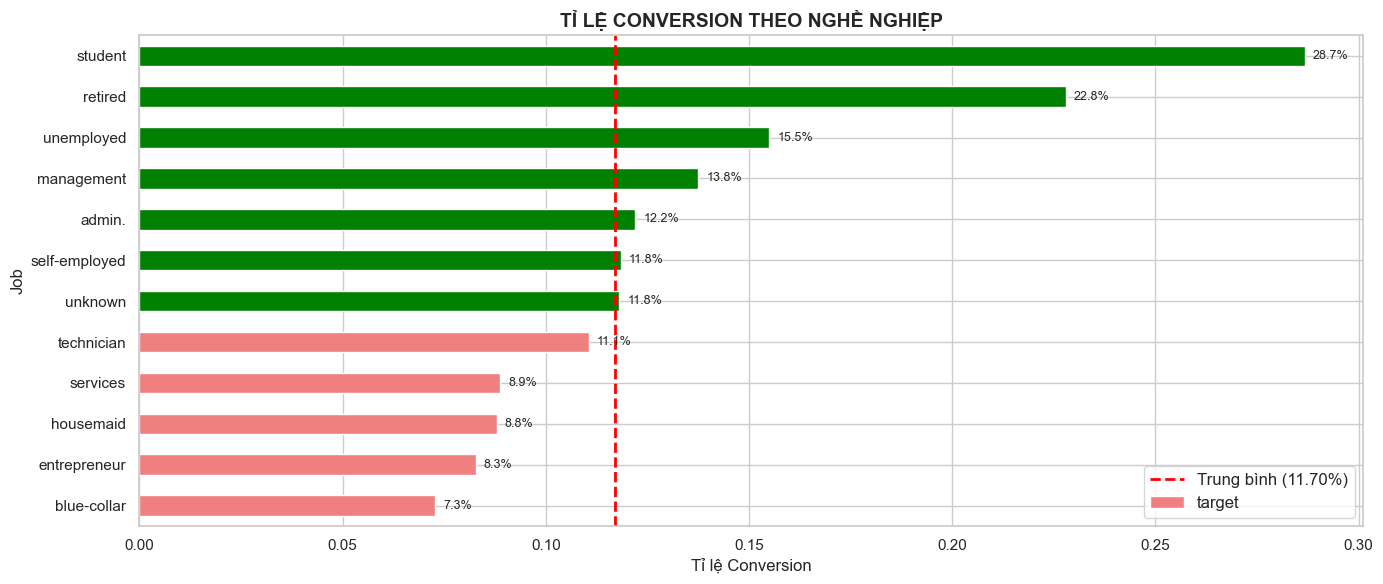


Top 3 nghề convert cao nhất: ['unemployed', 'retired', 'student']
Top 3 nghề convert thấp nhất: ['blue-collar', 'entrepreneur', 'housemaid']


In [64]:
# ============================================================
# Q1: Nghề nào convert cao nhất? (có đường trung bình)
# ============================================================
job_conv = df.groupby('job')['target'].mean().sort_values(ascending=True)

plt.figure(figsize=(14, 6))
colors = ['green' if v > avg_conv else 'lightcoral' for v in job_conv.values]
job_conv.plot(kind='barh', color=colors)
plt.axvline(x=avg_conv, color='red', linestyle='--', linewidth=2, label=f'Trung bình ({avg_conv:.2%})')
plt.title('TỈ LỆ CONVERSION THEO NGHỀ NGHIỆP', fontsize=14, fontweight='bold')
plt.xlabel('Tỉ lệ Conversion')
plt.ylabel('Job')
plt.legend(fontsize=12)

# Thêm % trên mỗi bar
for i, v in enumerate(job_conv.values):
    plt.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nTop 3 nghề convert cao nhất: {list(job_conv.tail(3).index)}')
print(f'Top 3 nghề convert thấp nhất: {list(job_conv.head(3).index)}')

C:\Users\acer\AppData\Local\Temp\ipykernel_28448\309657341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='campaign', data=df, ax=axes[0], palette=['lightcoral', 'lightgreen'])


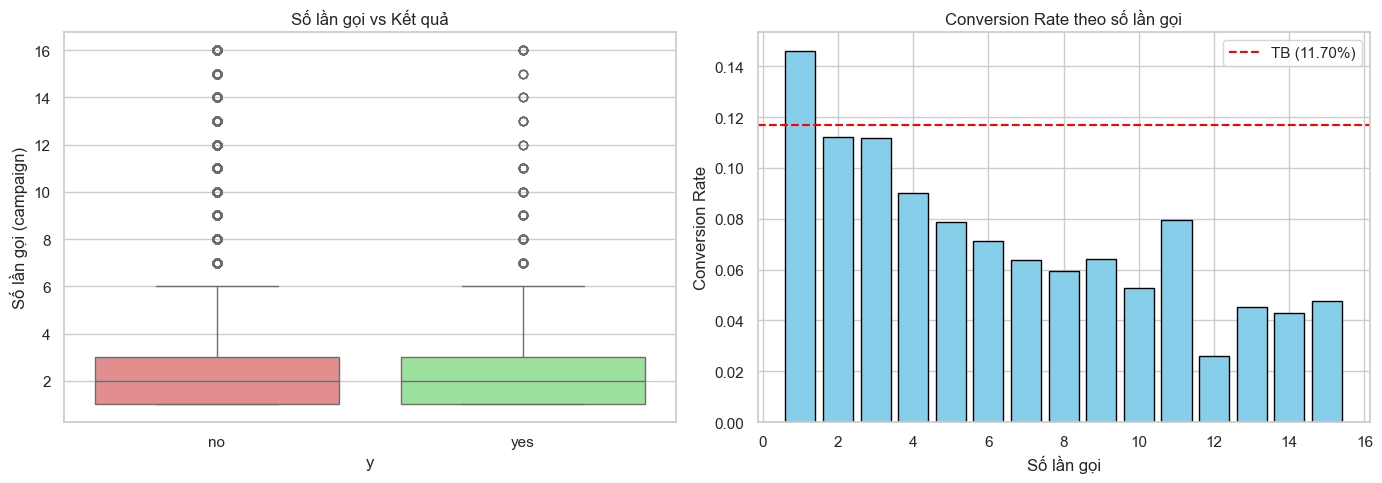

Insight: Gọi 1-3 lần hiệu quả nhất. Gọi quá nhiều lần => conversion giảm rõ rệt.


In [65]:
# ============================================================
# Q2: Campaign - Gọi bao nhiêu lần thì hiệu quả?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='y', y='campaign', data=df, ax=axes[0], palette=['lightcoral', 'lightgreen'])
axes[0].set_title('Số lần gọi vs Kết quả')
axes[0].set_ylabel('Số lần gọi (campaign)')

# Conversion rate theo số lần gọi
campaign_conv = df.groupby('campaign')['target'].mean()
campaign_conv = campaign_conv[campaign_conv.index <= 15]  # Giới hạn hiển thị
axes[1].bar(campaign_conv.index, campaign_conv.values, color='skyblue', edgecolor='black')
axes[1].axhline(y=avg_conv, color='red', linestyle='--', label=f'TB ({avg_conv:.2%})')
axes[1].set_title('Conversion Rate theo số lần gọi')
axes[1].set_xlabel('Số lần gọi')
axes[1].set_ylabel('Conversion Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Insight: Gọi 1-3 lần hiệu quả nhất. Gọi quá nhiều lần => conversion giảm rõ rệt.')

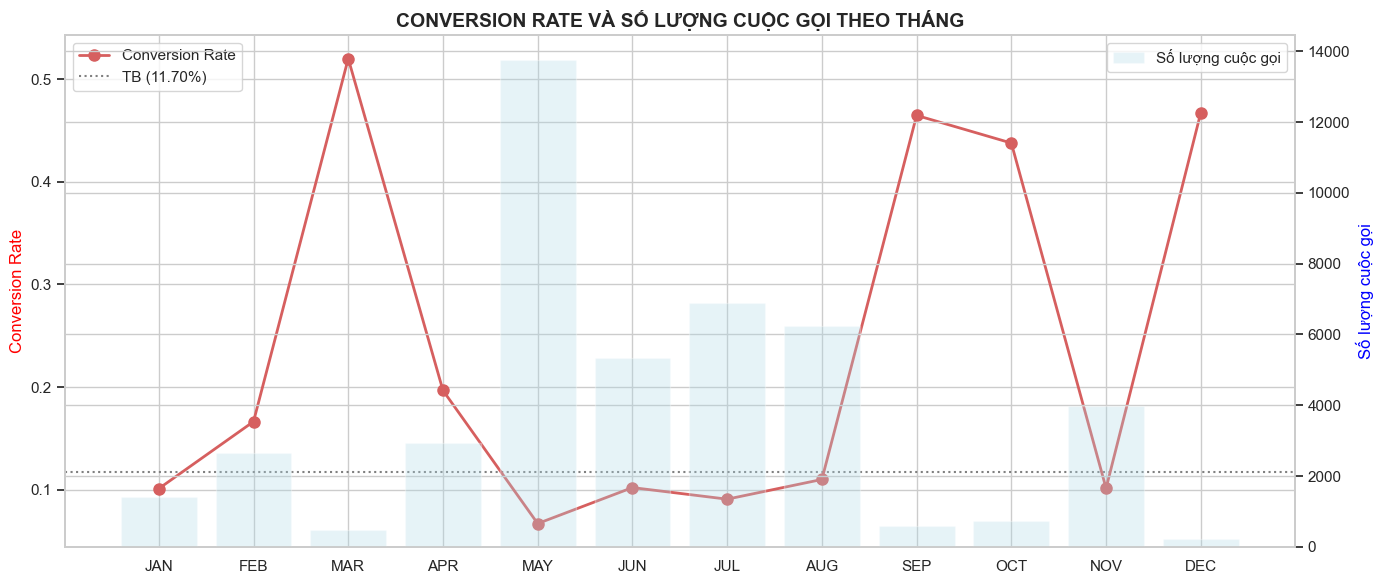

In [66]:
# ============================================================
# Q3: Tháng nào hiệu quả nhất?
# ============================================================
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_conv = df.groupby('month')['target'].agg(['mean', 'count']).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar = số lượng campaign
ax2 = ax1.twinx()
ax2.bar(range(len(month_order)), month_conv['count'], alpha=0.3, color='lightblue', label='Số lượng cuộc gọi')
ax2.set_ylabel('Số lượng cuộc gọi', color='blue')

# Line = conversion rate
ax1.plot(range(len(month_order)), month_conv['mean'], 'ro-', linewidth=2, markersize=8, label='Conversion Rate', zorder=5)
ax1.axhline(y=avg_conv, color='gray', linestyle=':', label=f'TB ({avg_conv:.2%})')
ax1.set_ylabel('Conversion Rate', color='red')
ax1.set_xticks(range(len(month_order)))
ax1.set_xticklabels([m.upper() for m in month_order])

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('CONVERSION RATE VÀ SỐ LƯỢNG CUỘC GỌI THEO THÁNG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

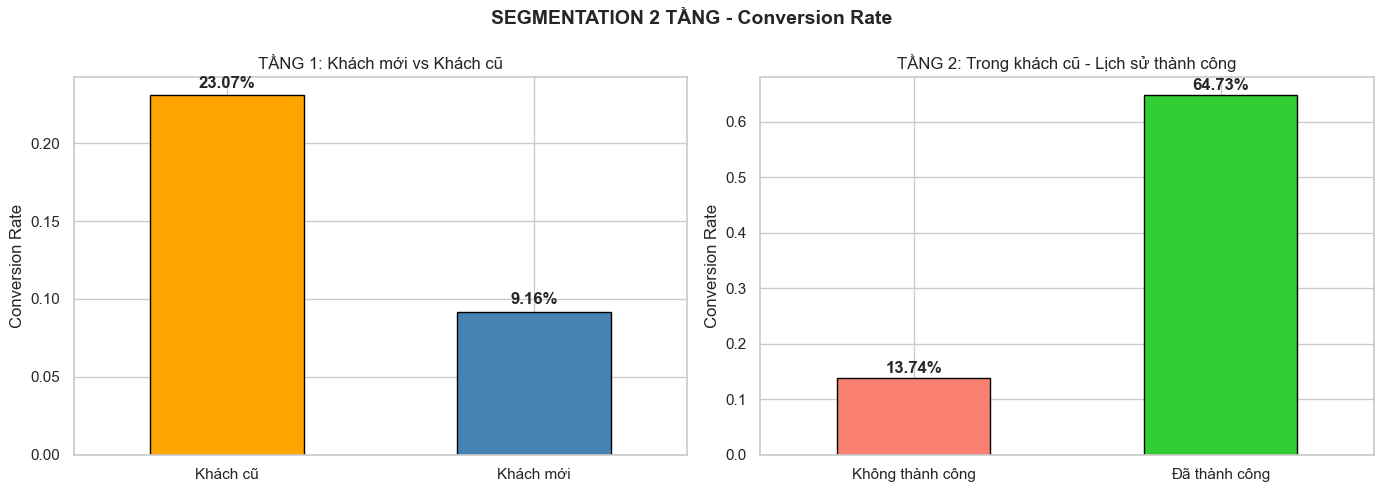

Insight: Khách cũ đã từng đồng ý (prev_success=1) có conversion rate CAO HƠN HẲN.
=> signal cực mạnh, nên ưu tiên gọi nhóm này.


In [67]:
# ============================================================
# Q4: Conversion theo segmentation 2 tầng
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tầng 1: Khách mới vs cũ
seg1 = df.groupby('is_new_customer')['target'].mean()
seg1.index = ['Khách cũ', 'Khách mới']
seg1.plot(kind='bar', ax=axes[0], color=['orange', 'steelblue'], edgecolor='black')
axes[0].set_title('TẦNG 1: Khách mới vs Khách cũ')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(seg1.index, rotation=0)
for i, v in enumerate(seg1.values):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

# Tầng 2: Trong khách cũ - thành công trước vs không
existing = df[df['is_new_customer'] == 0]
seg2 = existing.groupby('prev_success')['target'].mean()
seg2.index = ['Không thành công', 'Đã thành công']
seg2.plot(kind='bar', ax=axes[1], color=['salmon', 'limegreen'], edgecolor='black')
axes[1].set_title('TẦNG 2: Trong khách cũ - Lịch sử thành công')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(seg2.index, rotation=0)
for i, v in enumerate(seg2.values):
    axes[1].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.suptitle('SEGMENTATION 2 TẦNG - Conversion Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Khách cũ đã từng đồng ý (prev_success=1) có conversion rate CAO HƠN HẲN.')
print('=> signal cực mạnh, nên ưu tiên gọi nhóm này.')

---
## 5. TÓM TẮT DỮ LIỆU SAU XỬ LÝ

In [68]:
# ============================================================
# Tóm tắt cột sau xử lý
# ============================================================
print('=== CÁC CỘT TRONG DATASET SAU XỬ LÝ ===')
print(f'Tổng số cột: {len(df.columns)}')
print(f'Tổng số dòng: {len(df)}')
print()

# Phân loại cột
original_num = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
original_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
engineered = ['is_new_customer', 'prev_success', 'pdays_actual', 'contact_known']

print('--- Biến số gốc (đã xử lý balance âm + Winsorize) ---')
for c in original_num:
    if c in df.columns:
        print(f'  {c:>15}: min={df[c].min():<10} max={df[c].max():<10} mean={df[c].mean():.2f}')

print('\n--- Biến phân loại gốc ---')
for c in original_cat:
    if c in df.columns:
        print(f'  {c:>15}: {df[c].nunique()} giá trị unique')

print('\n--- Biến Feature Engineering ---')
for c in engineered:
    if c in df.columns:
        print(f'  {c:>20}: {df[c].value_counts().to_dict()}')

print('\n--- Biến target ---')
print(f'  y: {df["y"].value_counts().to_dict()}')
print(f'  target (binary): {df["target"].value_counts().to_dict()}')

=== CÁC CỘT TRONG DATASET SAU XỬ LÝ ===
Tổng số cột: 22
Tổng số dòng: 45211

--- Biến số gốc (đã xử lý balance âm + Winsorize) ---
              age: min=18         max=95         mean=40.94
          balance: min=0          max=13165      mean=1300.62
              day: min=1          max=31         mean=15.81
         duration: min=0          max=4918       mean=258.16
         campaign: min=1          max=16         mean=2.69
            pdays: min=-1         max=871        mean=40.20
         previous: min=0          max=275        mean=0.58

--- Biến phân loại gốc ---
              job: 12 giá trị unique
          marital: 3 giá trị unique
        education: 4 giá trị unique
          default: 2 giá trị unique
          housing: 2 giá trị unique
             loan: 2 giá trị unique
          contact: 3 giá trị unique
            month: 12 giá trị unique
         poutcome: 4 giá trị unique

--- Biến Feature Engineering ---
       is_new_customer: {1: 36954, 0: 8257}
          prev_s

---
## 6. CHIA DỮ LIỆU - Stratified Split 80/20
Giữ tỉ lệ yes/no đồng đều giữa train và test.

In [69]:
# ============================================================
# Chuẩn bị features
# ============================================================
# Bỏ: y (string gốc), target (label)
# Bỏ: pdays (đã thay bằng pdays_actual + is_new_customer)
# Bỏ: poutcome (đã encode thành prev_success + is_new_customer)
# Bỏ: duration (README nói cột này chỉ biết sau khi gọi, không dùng cho prediction)
# Bỏ: day (ít ý nghĩa)

cols_to_drop = ['y', 'target', 'pdays', 'poutcome', 'duration', 'day']
X = df.drop(columns=cols_to_drop)
y = df['target']

print(f'Features: {list(X.columns)}')
print(f'Shape: {X.shape}')

Features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'previous', 'is_new_customer', 'prev_success', 'pdays_actual', 'contact_known']
Shape: (45211, 16)


In [70]:
# ============================================================
# Encoding categorical -> One-Hot (drop_first=True tránh đa cộng tuyến)
# ============================================================
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

print(f'Categorical: {cat_features}')
print(f'Numerical: {num_features}')

X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True, dtype=int)
print(f'\nSau One-Hot Encoding: {X_encoded.shape[1]} cột')

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
Numerical: ['age', 'balance', 'campaign', 'previous', 'is_new_customer', 'prev_success', 'pdays_actual', 'contact_known']

Sau One-Hot Encoding: 40 cột


In [71]:
# ============================================================
# Stratified Split 80/20 - giữ tỉ lệ yes/no
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Verify tỉ lệ
print('=== KIỂM TRA TỈ LỆ SAU SPLIT ===')
print(f'Train: {len(X_train)} rows | Yes: {y_train.mean():.4f} | No: {1-y_train.mean():.4f}')
print(f'Test:  {len(X_test)} rows | Yes: {y_test.mean():.4f} | No: {1-y_test.mean():.4f}')
print(f'\n=> Tỉ lệ yes/no GIỐNG NHAU giữa train và test. Stratified split thành công!')

=== KIỂM TRA TỈ LỆ SAU SPLIT ===
Train: 36168 rows | Yes: 0.1170 | No: 0.8830
Test:  9043 rows | Yes: 0.1170 | No: 0.8830

=> Tỉ lệ yes/no GIỐNG NHAU giữa train và test. Stratified split thành công!


In [72]:
# ============================================================
# Z-Score Scaling
# CHỈ fit trên train, transform cả train và test
# QUAN TRỌNG: Lưu mask segmentation TRƯỚC khi scale
# vì scale sẽ đổi giá trị 0/1 thành z-score
# ============================================================

# Lưu mask trước khi scale (is_new_customer vẫn là 0/1 lúc này)
mask_new_train = X_train['is_new_customer'] == 1
mask_new_test = X_test['is_new_customer'] == 1

# Scale
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print('Z-Score stats (train):')
print(X_train[num_features].describe().round(3).loc[['mean', 'std', 'min', 'max']])
print('\n=> Mean ~ 0, Std ~ 1. Scaling OK!')

Z-Score stats (train):
        age  balance  campaign  previous  is_new_customer  prev_success  \
mean -0.000    0.000    -0.000    -0.000            0.000         0.000   
std   1.000    1.000     1.000     1.000            1.000         1.000   
min  -2.154   -0.583    -0.655    -0.242           -2.120        -0.186   
max   5.091    5.317     5.158   113.926            0.472         5.387   

      pdays_actual  contact_known  
mean         0.000          0.000  
std          1.000          1.000  
min         -0.410         -1.576  
max          8.315          0.635  

=> Mean ~ 0, Std ~ 1. Scaling OK!


---
## 7. SEGMENTATION - Train 2 Model riêng biệt

**Tư duy:**
- **Model A**: Học pattern của KHÁCH MỚI (is_new_customer=1)
- **Model B**: Học pattern của KHÁCH CŨ (is_new_customer=0), có thêm signal prev_success

Khi predict: Phân loại trước khách mới/cũ → chọn model tương ứng.

In [73]:
# ============================================================
# Chia train/test thành 2 segment
# Dùng mask đã lưu TRƯỚC khi scale
# ============================================================
# Segment A: Khách mới
X_train_new = X_train[mask_new_train]
y_train_new = y_train[mask_new_train]
X_test_new = X_test[mask_new_test]
y_test_new = y_test[mask_new_test]

# Segment B: Khách cũ
X_train_old = X_train[~mask_new_train]
y_train_old = y_train[~mask_new_train]
X_test_old = X_test[~mask_new_test]
y_test_old = y_test[~mask_new_test]

print('=== SEGMENTATION ===')
print(f'Model A (Khách mới) - Train: {len(X_train_new)}, Test: {len(X_test_new)}')
print(f'  Train yes rate: {y_train_new.mean():.4f}')
print(f'  Test  yes rate: {y_test_new.mean():.4f}')
print(f'\nModel B (Khách cũ) - Train: {len(X_train_old)}, Test: {len(X_test_old)}')
print(f'  Train yes rate: {y_train_old.mean():.4f}')
print(f'  Test  yes rate: {y_test_old.mean():.4f}')

=== SEGMENTATION ===
Model A (Khách mới) - Train: 29584, Test: 7370
  Train yes rate: 0.0922
  Test  yes rate: 0.0891

Model B (Khách cũ) - Train: 6584, Test: 1673
  Train yes rate: 0.2284
  Test  yes rate: 0.2397


In [74]:
# ============================================================
# MODEL A: Logistic Regression cho KHÁCH MỚI
# ============================================================
model_A = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_A.fit(X_train_new, y_train_new)

y_pred_A = model_A.predict(X_test_new)
y_proba_A = model_A.predict_proba(X_test_new)[:, 1]

print('=== MODEL A: KHÁCH MỚI ===')
print(classification_report(y_test_new, y_pred_A, target_names=['no', 'yes']))
print(f'ROC-AUC: {roc_auc_score(y_test_new, y_proba_A):.4f}')

=== MODEL A: KHÁCH MỚI ===
              precision    recall  f1-score   support

          no       0.95      0.70      0.81      6713
         yes       0.17      0.63      0.27       657

    accuracy                           0.69      7370
   macro avg       0.56      0.66      0.54      7370
weighted avg       0.88      0.69      0.76      7370

ROC-AUC: 0.7298


In [75]:
# ============================================================
# MODEL B: Logistic Regression cho KHÁCH CŨ
# ============================================================
model_B = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_B.fit(X_train_old, y_train_old)

y_pred_B = model_B.predict(X_test_old)
y_proba_B = model_B.predict_proba(X_test_old)[:, 1]

print('=== MODEL B: KHÁCH CŨ ===')
print(classification_report(y_test_old, y_pred_B, target_names=['no', 'yes']))
print(f'ROC-AUC: {roc_auc_score(y_test_old, y_proba_B):.4f}')

=== MODEL B: KHÁCH CŨ ===
              precision    recall  f1-score   support

          no       0.90      0.81      0.85      1272
         yes       0.54      0.71      0.61       401

    accuracy                           0.78      1673
   macro avg       0.72      0.76      0.73      1673
weighted avg       0.81      0.78      0.79      1673

ROC-AUC: 0.8238


In [76]:
# ============================================================
# SO SÁNH: Combined model vs 2 model riêng
# ============================================================
# Model chung (baseline)
model_all = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_all.fit(X_train, y_train)
y_proba_all = model_all.predict_proba(X_test)[:, 1]
auc_all = roc_auc_score(y_test, y_proba_all)

# Combined prediction từ 2 model
y_proba_combined = np.concatenate([y_proba_A, y_proba_B])
y_test_combined = pd.concat([y_test_new, y_test_old])
auc_combined = roc_auc_score(y_test_combined, y_proba_combined)

print('=== SO SÁNH KẾT QUẢ ===')
print(f'Model chung (1 model):      ROC-AUC = {auc_all:.4f}')
print(f'Segmentation (2 model):     ROC-AUC = {auc_combined:.4f}')
print(f'\nChênh lệch: {(auc_combined - auc_all):.4f}')
if auc_combined > auc_all:
    print('=> Segmentation 2 tầng CẢI THIỆN hiệu quả so với model chung!')
else:
    print('=> Model chung đã đủ tốt, nhưng segmentation vẫn giúp hiểu insight rõ hơn.')

=== SO SÁNH KẾT QUẢ ===
Model chung (1 model):      ROC-AUC = 0.7729
Segmentation (2 model):     ROC-AUC = 0.7548

Chênh lệch: -0.0181
=> Model chung đã đủ tốt, nhưng segmentation vẫn giúp hiểu insight rõ hơn.
